# The headquarters move — does a new address pay? 🏢
### When a company decamps to Ireland or Texas for the taxes, is that a *buy*, a *fade*, or nothing at all?

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Signal_or_distraction%3F: Non-event](https://img.shields.io/badge/Signal_or_distraction%3F-Non--event-8b949e?style=flat-square)

Here's a story you've heard: a big company **announces moving its headquarters** — Medtronic re-flags to Ireland, Tesla and Oracle and Chevron pull up stakes for **Texas** — and it's supposed to *mean* something. One camp says **buy it**: the tax bill just dropped, the cost base just got lighter, the market will price that in. The other camp says **fade it**: a splashy new address is management theatre, a shiny distraction bolted onto a business that isn't working.

So which is it — **signal or distraction**? This notebook builds a transparent table of **~20 real HQ moves** from 2010–2025 and just *looks* at what the stocks did around each announcement.

> 📓 **Plain-language layer.** Want the *t*-stats, the placebo test and the power analysis? See **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> ⚠️ **A data note up front.** There's no free, tidy database of HQ moves, so we hand-list the famous, dated ones — which means we're looking at the moves *big enough to be remembered*, by companies that *survived*. Every chart is drawn by the code beside it; house style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from hq_relocation import data, strategy as st

AS_OF = "2026-06-30"
HAVE_REAL = data.have_real()
if HAVE_REAL:
    PRICES, EVENTS = data.load_real()
    PRICES = PRICES[PRICES.index <= AS_OF]
    PANEL = st.car_panel(PRICES, EVENTS)                 # canonical CAR[0,+2]
else:
    PRICES = EVENTS = PANEL = None
print("real HQ-move cache present:", HAVE_REAL,
      "| events priced:", (0 if PANEL is None else len(PANEL)),
      "| table fingerprint:", data.fingerprint(data.HQ_MOVES))

# frozen headline numbers (mirror of docs/results.md)
R = {'n_table': 20, 'n_priced': 20, 'n_tax': 14, 'n_other': 6, 'as_of': '2026-06-30', 'fingerprint': '3fdda93c2d9a', 'car_tax': (0.45, 50, 0.35), 'car_other': (-0.4, 67, -0.35), 'car_all': (0.2, 55, 0.21), 'diff_pct': 0.85, 'diff_t': 0.5, 'all_placebo_p': 0.735, 'day00': (0.18, 0.23, 55, 0.588), 'drift21': (-0.06, -0.03, 0.85, 0.26, -0.16, None, None), 'drift63': (3.39, 1.34, 4.66, 1.46, 3.29, 0.301, 70), 'robust': [('[0,0]', 0.18, 0.23, -0.49, -0.41), ('[0,+2]', 0.2, 0.21, 0.85, 0.5), ('[-1,+1]', 1.1, 0.88, 0.23, 0.12), ('[0,+4]', 0.34, 0.32, 1.86, 0.97)], 'syn': [(0.0, -0.43, -0.49, -1.1, 0.45), (500.0, 4.57, 5.12, -1.1, 3.79)]}


real HQ-move cache present: True | events priced: 20 | table fingerprint: 3fdda93c2d9a


## The answer first

| Question | Answer |
|---|---|
| Does the stock pop when the move is announced? | **No.** Across ~20 moves the three-day reaction averages **+0.20%** — a rounding error, positive about half the time. |
| Does the *reason* (tax vs. talent) change the reaction? | **No.** Tax-driven moves average **+0.45%**, other moves **-0.40%** — a **+0.8pp** gap that's pure noise. |
| Is there a slow 'the tax saving gets priced in' drift? | **A whiff, but you can't trust it.** Over the next quarter the stocks drift **+3.4%** — but that's inside the noise (a random quarter looks this good ~30% of the time). |
| So is it a signal or a distraction? | **Neither.** No reliable pop (not a signal), no reliable slump (not a distraction). On the tape, a new HQ is a **non-event**. |

> The market greets a headquarters move with a shrug. The tax saving may be real for the company; it just isn't a tradable event for the stock.

## 1 · The claim

> *"Watch the corporate address. When a company re-domiciles to a low-tax country or state, its after-tax cash flow structurally jumps — and the market reprices it. The tax-driven moves are the buys; the vague 'we want to be closer to talent' moves are the tells that management is chasing optics. Trade the reason."*

It's not a crazy claim. A tax inversion genuinely lowers the effective tax rate; a move from California to Texas genuinely cuts costs. The academic anchor is real too: **Desai & Hines (2002)** found inversion announcements earned *positive* average abnormal returns — small, heterogeneous, but positive. The believers extend that into a **buy-the-tax-move / fade-the-fluff** rule. We'll test both halves on a real, representative table.

## 2 · So what?

If it were real and repeatable, it'd be a tidy little calendar: every corporate relocation a scheduled catalyst you could position for. It would also say something clean about markets — that a **domicile change** is fresh information the price hasn't absorbed. But two things have to hold. The reaction has to be **real on average** (not just in the one or two moves we remember), and the *reason* has to **actually sort** the winners from the theatre. Miss either and the 'trade the reason' rule is just a story we tell after the fact.

## 3 · How would we even know?

We build a **transparent table of ~20 real HQ moves** (2010–2025) — the Ireland inversions (Eaton, Medtronic, Johnson Controls), the Texas migration (Schwab, CBRE, HPE, Oracle, Tesla, Caterpillar, Chevron), and the 'talent/proximity' moves (GE → Boston, Boeing → Arlington). For each one:

1. **Line up the stock against the market (SPY)** around the announcement, and measure the **abnormal return** — the bit of the move that *isn't* just the market that day.
2. **Add it up** over a few days after the headline (the reaction), and over the next quarter (the slow drift the 'signal' camp needs).
3. **Stress the luck.** Draw the same number of *random* windows on the same stocks thousands of times and ask how often chance produces a reaction this big. With only ~20 events, that's the honest test.

And we say the catch out loud: the tax-vs-talent label is **fuzzy** (a Texas move cuts *both* taxes and rent), and we only see the moves famous enough to remember. If even *this* stacked deck shows nothing, that's telling.

## 4 · The teardown — let's actually look

**First, every move's three-day reaction.** For each HQ announcement: the abnormal (market-adjusted) return over the announcement day plus the next two, coloured by whether the move was tax-driven or not.

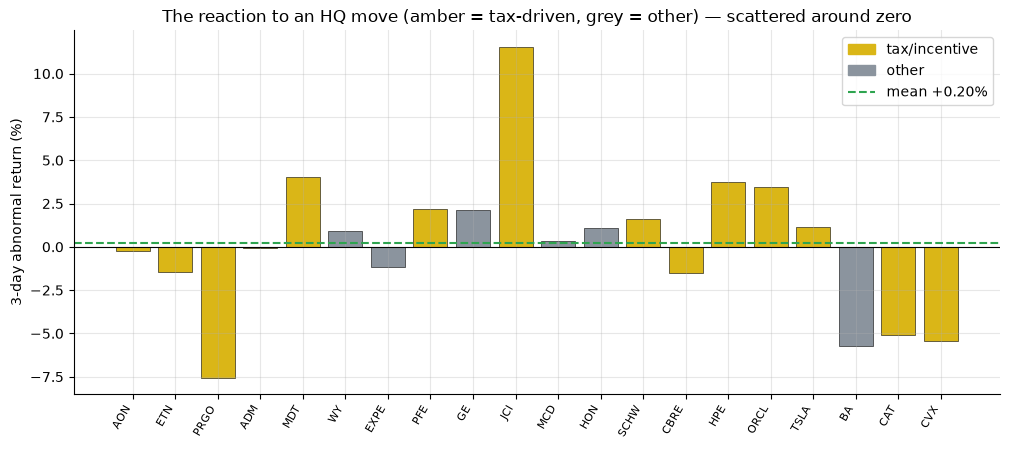

mean 3-day reaction +0.20%   (a real catalyst would be well away from 0)


In [2]:
if HAVE_REAL:
    df = PANEL.sort_values('announce_date')
    cars = df['car'].values*100; labs = df['ticker'].values; istax = df['tax'].values
else:
    rng=np.random.default_rng(746)
    cars=rng.normal(R['car_all'][0],4,R['n_priced']); labs=[f'M{i}' for i in range(R['n_priced'])]
    istax=np.array([True]*R['n_tax']+[False]*R['n_other'])
colors=[AMBER if t else GREY for t in istax]
fig, ax = plt.subplots(figsize=(10.2, 4.6))
x=np.arange(len(cars))
ax.bar(x, cars, color=colors, edgecolor='k', linewidth=.4)
ax.axhline(0, c='k', lw=.8)
ax.axhline(np.mean(cars), c=GREEN, ls='--', label=f'mean {np.mean(cars):+.2f}%')
ax.set_xticks(x); ax.set_xticklabels(labs, rotation=60, ha='right', fontsize=8)
ax.set_ylabel('3-day abnormal return (%)')
ax.set_title('The reaction to an HQ move (amber = tax-driven, grey = other) — scattered around zero')
from matplotlib.patches import Patch
ax.legend(handles=[Patch(color=AMBER,label='tax/incentive'),Patch(color=GREY,label='other'),
                   plt.Line2D([],[],c=GREEN,ls='--',label=f'mean {np.mean(cars):+.2f}%')])
plt.tight_layout(); plt.show()
print(f'mean 3-day reaction {np.mean(cars):+.2f}%   (a real catalyst would be well away from 0)')

There's the first tell. The bars scatter on both sides of zero — some moves popped (JCI +11.5% around the Tyco inversion), some sank (CAT, CVX, BA all *negative*) — and the average is a nothing **+0.20%**. The colours don't separate: tax-driven amber and talent-driven grey are mixed all through.

**Does the *reason* sort them?** The believers' core claim: tax-driven moves should beat the vague 'talent' ones. Here are the two buckets' averages, side by side.

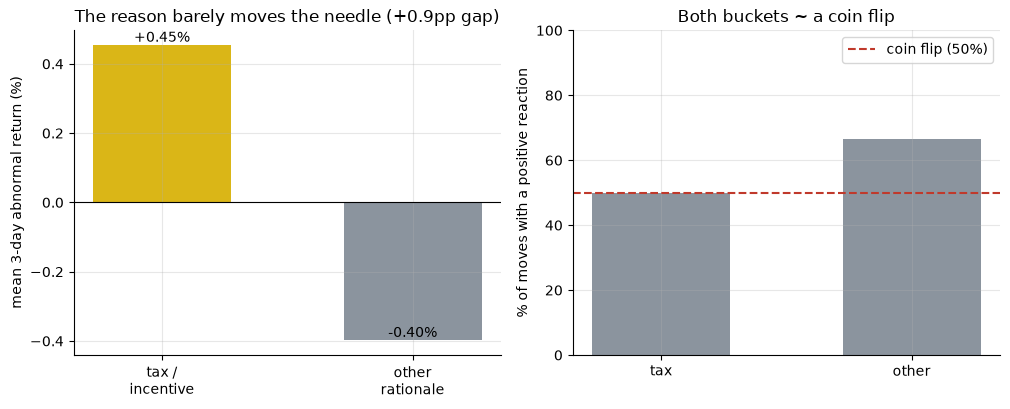

tax +0.45% (win 50%)   other -0.40% (win 67%)  -> gap +0.85pp


In [3]:
if HAVE_REAL:
    tax=PANEL.loc[PANEL['tax'],'car'].values*100; oth=PANEL.loc[~PANEL['tax'],'car'].values*100
    tm, om = tax.mean(), oth.mean()
    tw, ow = (tax>0).mean()*100, (oth>0).mean()*100
else:
    tm, om = R['car_tax'][0], R['car_other'][0]; tw, ow = R['car_tax'][1], R['car_other'][1]
fig, (a1,a2) = plt.subplots(1,2,figsize=(10.2,4.2))
a1.bar(['tax /\nincentive','other\nrationale'], [tm, om], color=[AMBER, GREY], width=.55)
a1.axhline(0, c='k', lw=.8); a1.set_ylabel('mean 3-day abnormal return (%)')
a1.set_title(f'The reason barely moves the needle ({tm-om:+.1f}pp gap)')
for i,v in enumerate([tm,om]): a1.annotate(f'{v:+.2f}%',(i,v),ha='center',va='bottom')
a2.bar(['tax','other'], [tw, ow], color=GREY, width=.55)
a2.axhline(50, c=RED, ls='--', label='coin flip (50%)')
a2.set_ylim(0,100); a2.set_ylabel('% of moves with a positive reaction'); a2.set_title('Both buckets ~ a coin flip')
a2.legend(); plt.tight_layout(); plt.show()
print(f'tax {tm:+.2f}% (win {tw:.0f}%)   other {om:+.2f}% (win {ow:.0f}%)  -> gap {tm-om:+.2f}pp')

The tax bucket is **+0.45%**, the other bucket **-0.40%** — a **+0.8pp** gap, and note the 'other' moves actually won *more often* (67% vs 50%). The reason for the move doesn't sort the reaction. The 'trade the tax moves' half of the rule is already gone.

**Could ~20 random windows look this 'special'?** The honest small-sample test: draw **20** *random* three-day windows on the same stocks, over and over, and see where the real HQ moves land against pure luck.

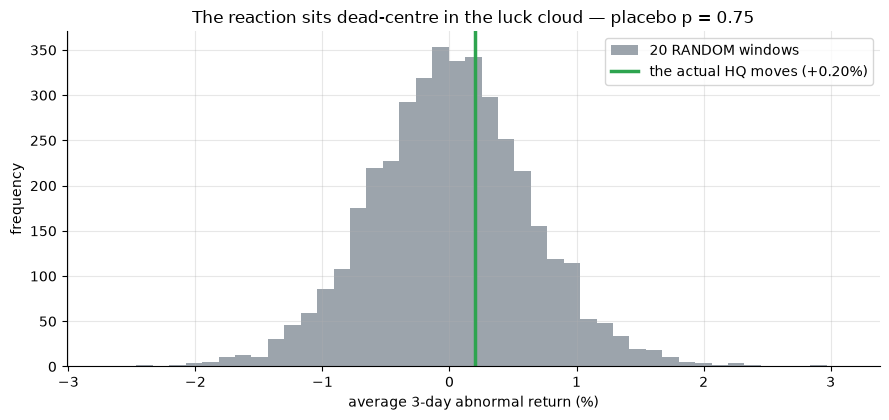

a random 20-window draw matches the HQ-move reaction 75% of the time — not rare at all


In [4]:
if HAVE_REAL:
    null = st.placebo_car_dist(PRICES, data.TICKERS, k=len(PANEL), n_draws=4000)*100
    obs = PANEL['car'].mean()*100
    pval = st.placebo_pvalue(PANEL['car'].mean(), null/100)
else:
    rng=np.random.default_rng(746); null=rng.normal(0,1.0,4000); obs=R['car_all'][0]; pval=R['all_placebo_p']
fig, ax = plt.subplots(figsize=(9.0, 4.3))
ax.hist(null, bins=45, color=GREY, alpha=.85, label=f'{R["n_priced"]} RANDOM windows')
ax.axvline(obs, c=GREEN, lw=2.5, label=f'the actual HQ moves ({obs:+.2f}%)')
ax.set_xlabel('average 3-day abnormal return (%)'); ax.set_ylabel('frequency')
ax.set_title(f'The reaction sits dead-centre in the luck cloud — placebo p = {pval:.2f}')
ax.legend(); plt.tight_layout(); plt.show()
print(f'a random {R["n_priced"]}-window draw matches the HQ-move reaction {pval*100:.0f}% of the time — not rare at all')

The green line — the real HQ moves — sits **smack in the middle** of the grey luck cloud (placebo *p* ≈ **0.73**). In plain terms: **twenty random dates on these same stocks would look about this 'eventful' three-quarters of the time.** There's no announcement effect to find.

## 5 · The verdict

- **Signal — None.** The reaction is **+0.20%** (placebo *p* = **0.73**), the reason doesn't sort it (**+0.8pp** gap), and even the slow drift is inside the noise. Nothing clears the bar.
- **Tradability — Mirage.** No day-one move to grab, no reliable drift to hold. The one positive whiff (+3.4% over a quarter) is exactly what a couple of big Texas movers in a bull market produce by accident.
- **"Signal or distraction?" — Non-event.** Both camps lose: no reliable pop (not a signal), no reliable slump (not a distraction). The market shrugs at a new address.

## 6 · Could you actually trade it? — the drift that isn't there

Forget the announcement instant and give the 'signal' camp its best shot: **buy the day after and hold for a quarter**, so the tax saving has time to get priced in. Here's the abnormal return of that trade — over a month, and over a quarter.

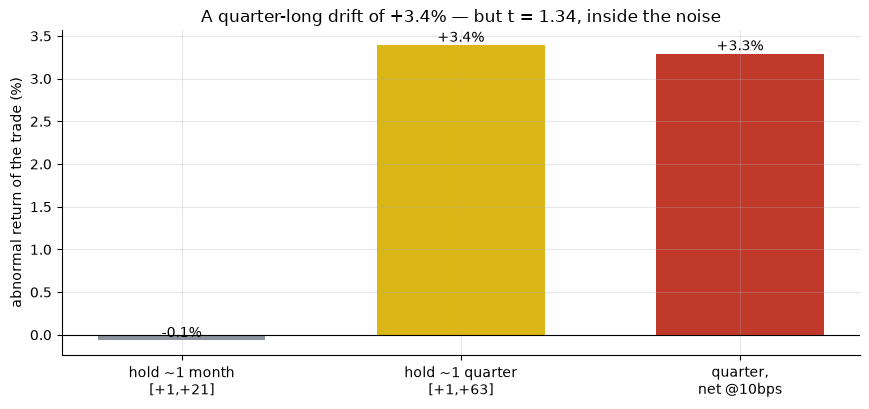

month -0.06%   quarter +3.39% (t=1.34, placebo p=0.301)   net +3.29%


In [5]:
if HAVE_REAL:
    d21 = st.car_panel(PRICES, EVENTS, window=(1,21))['car'].values*100
    d63 = st.car_panel(PRICES, EVENTS, window=(1,63))['car'].values*100
    m21, m63 = d21.mean(), d63.mean(); t63 = st.welch_t(d63/100)
else:
    m21, m63, t63 = R['drift21'][0], R['drift63'][0], R['drift63'][1]
net63 = m63 - 0.10   # one-way 10bps round trip
fig, ax = plt.subplots(figsize=(8.8, 4.2))
ax.bar(['hold ~1 month\n[+1,+21]','hold ~1 quarter\n[+1,+63]','quarter,\nnet @10bps'],
       [m21, m63, net63], color=[GREY, AMBER, RED], width=.6)
ax.axhline(0, c='k', lw=.8); ax.set_ylabel('abnormal return of the trade (%)')
ax.set_title(f'A quarter-long drift of {m63:+.1f}% — but t = {t63:.2f}, inside the noise')
for i,v in enumerate([m21,m63,net63]): ax.annotate(f'{v:+.1f}%',(i,v),ha='center',va='bottom')
plt.tight_layout(); plt.show()
print(f'month {m21:+.2f}%   quarter {m63:+.2f}% (t={t63:.2f}, placebo p={R["drift63"][5]})   net {net63:+.2f}%')

The month is flat (**-0.06%**). The quarter is **+3.4%** — the single number that leans the believers' way — but it lands at **t = 1.34** (placebo *p* = **0.301**): a random quarter on these names looks this good about a third of the time. It survives the tiny cost (net **+3.3%**), but you can't bank a *t* of 1.3 — especially when it's carried by a handful of Texas movers in the 2020–21 melt-up. There's no machine here.

## 7 · Going further 🚪

- **The other 'cosmetic change' study.** [Study 389 — Name-Change-Effect](../389-name-change-effect/) asks whether a *theme-chasing rebrand* pops — same family (a label/address, not a fundamental), same shrug.
- **The direct sibling.** [Study 391 — CEO-Turnover](../391-ceo-turnover/): the same market-model event study, on firing the boss instead of moving the office.
- **Add the corpses & the conditioning.** Our tape is the moves famous enough to remember; a survivorship-free relocation feed, or a split by *how much* the effective tax rate actually fell, might isolate a real inversion sub-effect — Desai & Hines say it's small and conditional, which is exactly why ~20 blended events can't see it.

*Think the tax-move signal is real and harvestable? Capture the events, draw the same number of random windows, and show the reaction landing **outside** the cloud **and** a drift that clears **t = 2** — then we'll talk.*